## Ноутбук с разведочным анализом данных и созданием новых признаков

1. Импорт бибилиотек и конфигурация проекта

In [ ]:
# Создадим словарь конфигураций.

CONFIG = {
    # Константы
    "DEV_MODE": False,
    "DEV_SAMPLE_SIZE": 100000,
    "RANDOM_STATE": 42,
    # Целевая переменная 
    "TARGET": "Цена",
    # Колонки с категориальными признаками (выявлены в процессе EDA)
    "CAT_COLS": ['Название машины', 'Тип двигателя', 'Коробка передач', 'Привод', 'Руль', 'Цвет', 'Комплектация', 'Тип кузова', 'Марка', 'Город', 'Регион', 'Макро-регион', 'Владельцы']
}

In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import pyarrow

In [ ]:
df = pd.read_parquet("../data/processed/train_cleaned.parquet")

2. Проверка на адекватность

In [ ]:
df.head(5)

,Название машины,Год,Объем двигателя,Тип двигателя,Мощность,Коробка передач,Привод,Пробег,Руль,Поколение,...,Цвет,Комплектация,Тип кузова,Марка,Город,Регион,Макро-регион,Владельцы,Есть особые отметки,Цена
456584,Toyota Corolla Spacio,2003.0,1.5,бензин,109.0,АКПП,передний,228000.0,правый,2.0,...,серый,1.5 X G edition,минивэн,toyota,Якутск,Республика Саха,ДФО,4 и более,0,650000.0
476657,Toyota Corolla,2007.0,1.6,бензин,124.0,РКПП,передний,237000.0,левый,10.0,...,голубой,1.6 MultiMode Престиж,седан,toyota,Рославль,Смоленская область,ЦФО,2,0,800000.0
436621,Subaru Legacy,1994.0,2.2,бензин,136.0,АКПП,4WD,200000.0,левый,1.0,...,бордовый,2.2 AT Classic Super-Station,универсал,subaru,Москва,Москва,Москва,4 и более,1,100000.0
479257,Toyota Camry,2007.0,3.5,бензин,277.0,АКПП,передний,319801.0,левый,7.0,...,черный,3.5 AT Luxe,седан,toyota,Иркутск,Иркутская область,СФО,4 и более,0,790000.0
340053,Mitsubishi Colt,1996.0,1.3,бензин,75.0,АКПП,передний,246000.0,левый,5.0,...,зеленый,1.3 AT GLX,хэтчбек 3 дв.,mitsubishi,Солнечногорск,Московская область,ЦФО,3,0,250000.0


In [ ]:
df.shape

(464926, 21)

In [ ]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(cat_cols)

['Название машины', 'Тип двигателя', 'Коробка передач', 'Привод', 'Руль', 'Цвет', 'Комплектация', 'Тип кузова', 'Марка', 'Город', 'Регион', 'Макро-регион', 'Владельцы']


C:\Users\Степан\AppData\Local\Temp\ipykernel_18696\1233978785.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns.tolist()


3. Анализ целевой переменной

<Axes: xlabel='Цена', ylabel='Count'>

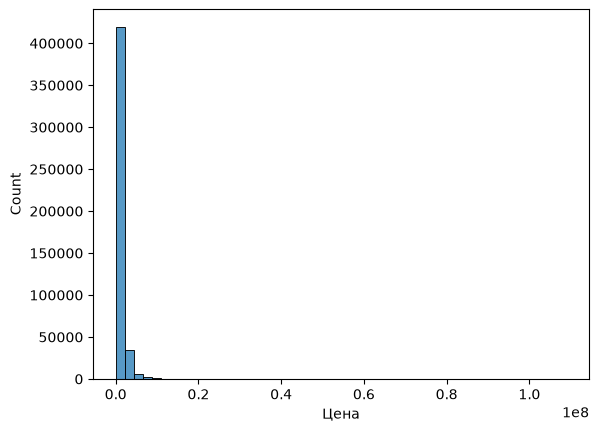

In [ ]:
sns.histplot(data=df, x=CONFIG["TARGET"], bins=50)

Заметим, что распределение целевой переменной обладает сильной правосторонней асимметрией (длинным правым хвостом). В дальнейшем планируется прологарифмировать таргет, чтобы приблизить его распределение к нормальному (симметричному)

4. Одномерный анализ признаков

4.1 Числовые признаки

In [ ]:
print(num_cols)

['Год', 'Объем двигателя', 'Мощность', 'Пробег', 'Поколение', 'Рестайлинг', 'Есть особые отметки', 'Цена']


<Axes: xlabel='Объем двигателя'>

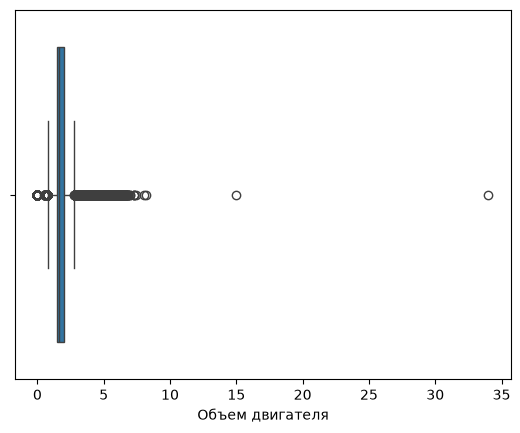

In [ ]:
sns.boxplot(data=df, x='Объем двигателя')

Точки в районе нуля - электромобили. Убедимся в этом:

In [ ]:
df.sort_values(by='Объем двигателя', ascending=True).head(5)

,Название машины,Год,Объем двигателя,Тип двигателя,Мощность,Коробка передач,Привод,Пробег,Руль,Поколение,...,Цвет,Комплектация,Тип кузова,Марка,Город,Регион,Макро-регион,Владельцы,Есть особые отметки,Цена
396198,Nissan Leaf,2016.0,0.0,электро,109.0,редуктор,передний,108.0,правый,1.0,...,золотистый,24kWh G//24kWh G Aero Style//24kWh G Aero Styl...,хэтчбек 5 дв.,nissan,Томск,Томская область,СФО,1,0,800000.0
368779,Nissan Leaf,2016.0,0.0,электро,109.0,редуктор,передний,120000.0,правый,1.0,...,бордовый,30kWh X Thanks Edition,хэтчбек 5 дв.,nissan,Усолье-Сибирское,Иркутская область,СФО,1,0,750000.0
377626,Nissan Leaf,2018.0,0.0,электро,150.0,редуктор,передний,69000.0,правый,2.0,...,серебристый,40kWh X,хэтчбек 5 дв.,nissan,Хабаровск,Хабаровский край,ДФО,1,0,1520000.0
380270,Nissan Leaf,2018.0,0.0,электро,150.0,редуктор,передний,100000.0,правый,2.0,...,белый,40kWh G,хэтчбек 5 дв.,nissan,Иркутск,Иркутская область,СФО,1,0,1550000.0
391206,Nissan Leaf,2014.0,0.0,электро,109.0,редуктор,передний,146000.0,правый,1.0,...,белый,X Aero Style,хэтчбек 5 дв.,nissan,Иркутск,Иркутская область,СФО,1,0,720000.0


Удалим явные выбросы:

In [ ]:
df = df[df['Объем двигателя'] < 10.0]


<Axes: xlabel='Мощность'>

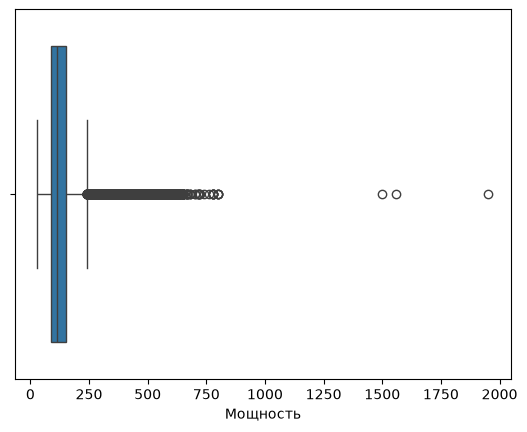

In [ ]:
sns.boxplot(data=df, x='Мощность')

In [ ]:
df = df[df['Мощность'] <= 1500]

<Axes: xlabel='Пробег'>

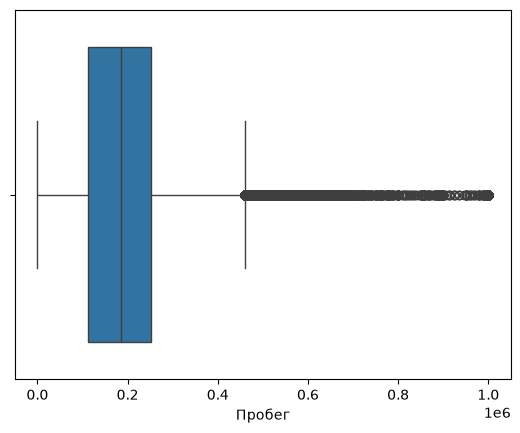

In [ ]:
sns.boxplot(data=df, x='Пробег')

4.2 Категориальные признаки

In [ ]:
print(cat_cols)

['Название машины', 'Тип двигателя', 'Коробка передач', 'Привод', 'Руль', 'Цвет', 'Комплектация', 'Тип кузова', 'Марка', 'Город', 'Регион', 'Макро-регион', 'Владельцы']


In [ ]:
df['Владельцы'].value_counts()

Владельцы
4 и более    241712
1             97696
3             62704
2             61497
1.0             930
2.0             218
3.0             165
Name: count, dtype: int64